# Notebook 06: ResNet50 Baseline Training

## Objective

Train a pretrained ResNet50 model for multi-class pneumonia classification using the processed pediatric chest X-ray dataset.

## Workflow

1. Import Libraries
2. Configuration
3. Dataset Loading
4. Model Initialization
5. Training
6. Validation
7. Testing
8. Performance Evaluation
9. Model Saving

## Import Required Libraries

In [41]:
# ============================================================
# Import Required Libraries
# ============================================================

import copy
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from torchvision.models import (
    efficientnet_b2,
    EfficientNet_B2_Weights
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("=" * 60)
print("✅ All libraries imported successfully.")
print("=" * 60)

✅ All libraries imported successfully.


## Project Paths

In [42]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path(
    "/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI"
)

DATASET_DIR = PROJECT_ROOT / "dataset" / "processed_dataset"

MODELS_DIR = PROJECT_ROOT / "models"

RESULTS_DIR = PROJECT_ROOT / "results"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "best_model.pth"
CHECKPOINT_PATH = MODELS_DIR / "last_checkpoint.pth"

HISTORY_PATH = RESULTS_DIR / "training_history.csv"

print(PROJECT_ROOT)

/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI


## Device Configuration

In [43]:
# ============================================================
# Device
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)

print("Device :", DEVICE)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print("CUDA :", torch.version.cuda)

print("="*60)

Device : cuda
GPU : NVIDIA GeForce RTX 3050
CUDA : 12.6


## Reproducibility

In [44]:
# ============================================================
# Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Seed :", SEED)

Seed : 42


## Training Configuration

In [45]:
# ============================================================
# Hyperparameters
# ============================================================

IMAGE_SIZE = 260

BATCH_SIZE = 16

EPOCHS = 30

LEARNING_RATE = 1e-4

NUM_CLASSES = 3

NUM_WORKERS = 0

CLASS_NAMES = [
    "BACTERIA",
    "NORMAL",
    "VIRUS"
]

print("="*60)

print(f"Image Size    : {IMAGE_SIZE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Epochs        : {EPOCHS}")
print(f"Learning Rate : {LEARNING_RATE}")

print("="*60)

Image Size    : 260
Batch Size    : 16
Epochs        : 30
Learning Rate : 0.0001


## Data Augmentation

Apply data augmentation for the training dataset and standard preprocessing for the validation and test datasets.

In [46]:
# ============================================================
# Data Augmentation
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.10,
        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

valid_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

])

print("✅ Data augmentation created successfully.")

✅ Data augmentation created successfully.


## Load Dataset

Load the processed dataset using the ImageFolder class.

In [47]:
# ============================================================
# Load Dataset
# ============================================================

train_dataset = datasets.ImageFolder(
    DATASET_DIR / "train",
    transform=train_transform
)

validation_dataset = datasets.ImageFolder(
    DATASET_DIR / "validation",
    transform=valid_transform
)

test_dataset = datasets.ImageFolder(
    DATASET_DIR / "test",
    transform=valid_transform
)

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


## Verify Dataset Information

Display the number of images and class mappings.

In [48]:
# ============================================================
# Dataset Information
# ============================================================

print("=" * 60)

print(f"Training Images   : {len(train_dataset)}")
print(f"Validation Images : {len(validation_dataset)}")
print(f"Test Images       : {len(test_dataset)}")

print("\nClass Mapping")

for class_name, class_index in train_dataset.class_to_idx.items():

    print(f"{class_name:<12} : {class_index}")

print("=" * 60)

Training Images   : 4099
Validation Images : 878
Test Images       : 879

Class Mapping
BACTERIA     : 0
NORMAL       : 1
VIRUS        : 2


## Create DataLoaders

Create PyTorch DataLoaders for efficient mini-batch loading.

In [49]:
# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("✅ DataLoaders created successfully.")

✅ DataLoaders created successfully.


## Visualize a Training Batch

Display a sample batch of training images after preprocessing.

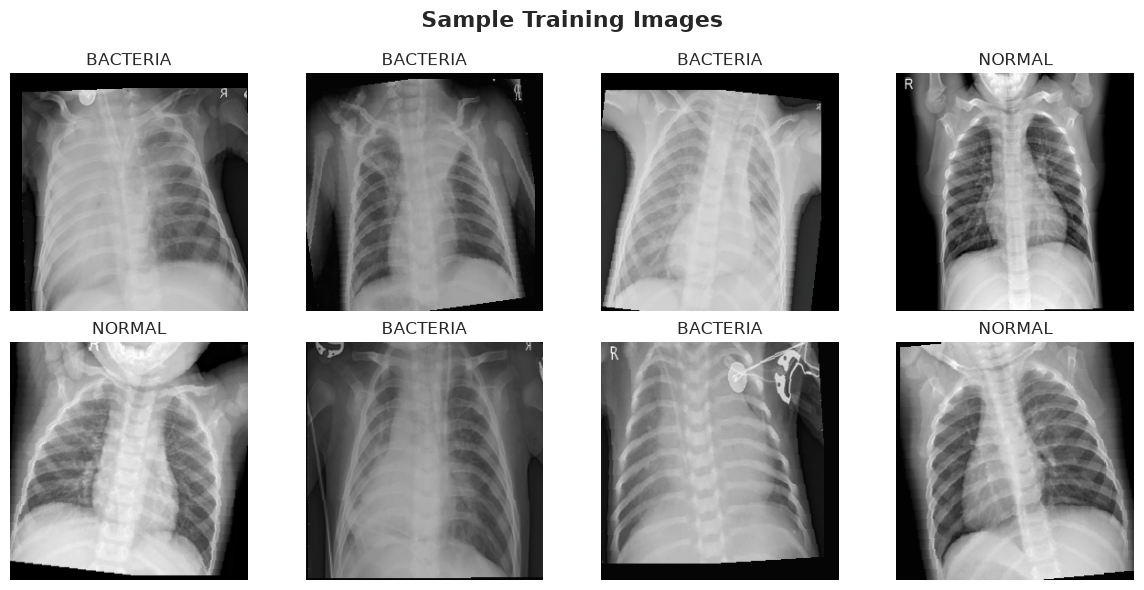

In [50]:
# ============================================================
# Visualize Training Batch
# ============================================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, image, label in zip(axes.flat, images[:8], labels[:8]):

    image = image.permute(1, 2, 0).numpy()

    image = image * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])

    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")

plt.suptitle(
    "Sample Training Images",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## Create EfficientNet Model

Initialize the pretrained EfficientNet model and modify the final classification layer for three-class pneumonia classification.

In [51]:
# ============================================================
# Create EfficientNet-B2 Model
# ============================================================

weights = EfficientNet_B2_Weights.DEFAULT

model = efficientnet_b2(weights=weights)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

model = model.to(DEVICE)

print(model.classifier)
print("\n✅ EfficientNet-B2 initialized successfully.")

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=1408, out_features=3, bias=True)
  )
)

✅ EfficientNet-B2 initialized successfully.


## Compute Class Weights

Calculate class weights to reduce the effect of class imbalance during training.

In [52]:
# ============================================================
# Compute Class Weights
# ============================================================

labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Class Weights:")
print(class_weights)

Class Weights:
tensor([0.7021, 1.2332, 1.3075], device='cuda:0')


## Define Loss Function, Optimizer and Learning Rate Scheduler

Configure the loss function, optimizer and learning rate scheduler.

In [53]:
# ============================================================
# Loss Function
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

# ============================================================
# Optimizer
# ============================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=5e-4
)

# ============================================================
# Scheduler
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("✅ Training components created successfully.")

✅ Training components created successfully.


## Mixed Precision Training

Enable Automatic Mixed Precision (AMP) to reduce GPU memory usage and improve training speed.

In [54]:
# ============================================================
# Automatic Mixed Precision
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("AMP Enabled:", torch.cuda.is_available())

AMP Enabled: True


## Training Variables

Initialize variables required for training, checkpointing, early stopping and training history.

In [55]:
# ============================================================
# Training Variables
# ============================================================

EARLY_STOPPING_PATIENCE = 7

best_accuracy = 0.0
best_epoch = 0

early_stop_counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "validation_loss": [],
    "validation_accuracy": []
}

print("✅ Training variables initialized.")

✅ Training variables initialized.


## Training and Validation Functions

Define reusable functions for one epoch of training and validation.

In [56]:
# ============================================================
# Training Function
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, scaler):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


# ============================================================
# Validation Function
# ============================================================

def validate_one_epoch(model, dataloader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with torch.amp.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):

                outputs = model(images)

                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("✅ Training functions created successfully.")

✅ Training functions created successfully.


## Checkpoint Management

Save and restore checkpoints for interrupted training sessions.

In [57]:
# ============================================================
# Checkpoint Paths
# ============================================================

CHECKPOINT_PATH = MODELS_DIR / "last_checkpoint.pth"

BEST_MODEL_PATH = MODELS_DIR / "best_model.pth"

HISTORY_PATH = RESULTS_DIR / "training_history.csv"


# ============================================================
# Save Best Model
# ============================================================

def save_best_model():

    torch.save(
        model.state_dict(),
        BEST_MODEL_PATH
    )


# ============================================================
# Safe Checkpoint Saving
# ============================================================

def save_checkpoint(epoch):

    checkpoint = {

        "epoch": epoch,

        "best_accuracy": best_accuracy,

        "best_epoch": best_epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "scaler_state_dict": scaler.state_dict()

    }

    temp_file = CHECKPOINT_PATH.with_suffix(".tmp")

    torch.save(checkpoint, temp_file)

    temp_file.replace(CHECKPOINT_PATH)


print("✅ Checkpoint functions ready.")

✅ Checkpoint functions ready.


## Resume Training

Resume training automatically if a valid checkpoint is available.

In [58]:
# ============================================================
# Resume Training
# ============================================================

START_EPOCH = 0

RESUME_TRAINING = True

if RESUME_TRAINING and CHECKPOINT_PATH.exists():

    try:

        checkpoint = torch.load(
            CHECKPOINT_PATH,
            map_location=DEVICE
        )

        model.load_state_dict(
            checkpoint["model_state_dict"]
        )

        optimizer.load_state_dict(
            checkpoint["optimizer_state_dict"]
        )

        scheduler.load_state_dict(
            checkpoint["scheduler_state_dict"]
        )

        scaler.load_state_dict(
            checkpoint["scaler_state_dict"]
        )

        START_EPOCH = checkpoint["epoch"] + 1

        best_accuracy = checkpoint["best_accuracy"]

        best_epoch = checkpoint["best_epoch"]

        print(f"✅ Resuming from Epoch {START_EPOCH}")

    except Exception:

        print("⚠️ Checkpoint is corrupted.")
        print("Starting a new training session.")

        START_EPOCH = 0

else:

    print("Starting a new training session.")

✅ Resuming from Epoch 11


## Model Training

Train the EfficientNet-B2 model while automatically saving the best model, checkpoints, and training history.

In [59]:
# ============================================================
# Model Training
# ============================================================

print("=" * 70)
print("🚀 Training Started")
print("=" * 70)

start_time = time.time()

for epoch in range(START_EPOCH, EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        validation_loader,
        criterion
    )

    scheduler.step(val_acc)

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["validation_loss"].append(val_loss)
    history["validation_accuracy"].append(val_acc)

    pd.DataFrame(history).to_csv(
        HISTORY_PATH,
        index=False
    )

    if val_acc > best_accuracy:

        best_accuracy = val_acc
        best_epoch = epoch + 1

        save_best_model()

        print("⭐ Best Model Saved")

        early_stop_counter = 0

    else:

        early_stop_counter += 1

    save_checkpoint(epoch)

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Train Acc : {train_acc:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f} | "
        f"Val Acc : {val_acc:.4f}"
    )

    print(
        f"Best Val Accuracy : {best_accuracy:.4f}"
    )

    if early_stop_counter >= EARLY_STOPPING_PATIENCE:

        print("\n🛑 Early Stopping Triggered")
        break

elapsed = (time.time() - start_time) / 60

print("\n" + "="*70)
print("✅ Training Completed")
print("="*70)

print(f"Best Epoch : {best_epoch}")
print(f"Best Validation Accuracy : {best_accuracy:.4f}")
print(f"Training Time : {elapsed:.2f} minutes")

🚀 Training Started

Epoch [12/30]


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Train Loss : 0.3819 | Train Acc : 0.9656
Val Loss   : 0.6453 | Val Acc : 0.8303
Best Val Accuracy : 0.8485

Epoch [13/30]


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Train Loss : 0.3655 | Train Acc : 0.9737
Val Loss   : 0.6498 | Val Acc : 0.8451
Best Val Accuracy : 0.8485

Epoch [14/30]


...

Train Loss : 0.3400 | Train Acc : 0.9912
Val Loss   : 0.6447 | Val Acc : 0.8440
Best Val Accuracy : 0.8485

Epoch [17/30]


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Train Loss : 0.3337 | Train Acc : 0.9939
Val Loss   : 0.6562 | Val Acc : 0.8337
Best Val Accuracy : 0.8485

Epoch [18/30]


Training:   0%|          | 0/257 [00:00<?, ?it/s]

Train Loss : 0.3315 | Train Acc : 0.9946
Val Loss   : 0.6504 | Val Acc : 0.8428
Best Val Accuracy : 0.8485

🛑 Early Stopping Triggered

✅ Training Completed
Best Epoch : 11
Best Validation Accuracy : 0.8485
Training Time : 17.52 minutes


## Test Set Evaluation

Load the best saved model and evaluate its performance on the independent test dataset.

In [60]:
# ============================================================
# Test Evaluation
# ============================================================

model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

correct = 0
total = 0

test_loss = 0

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

test_accuracy = correct / total
test_loss /= total

print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

print("="*60)

  0%|          | 0/55 [00:00<?, ?it/s]

Test Loss     : 0.5954
Test Accuracy : 0.8692


## Training Curves

Visualize the training history using loss and accuracy curves.

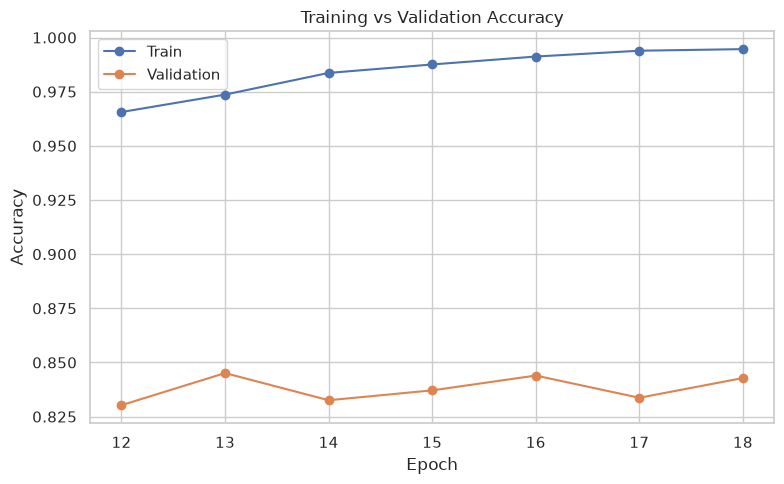

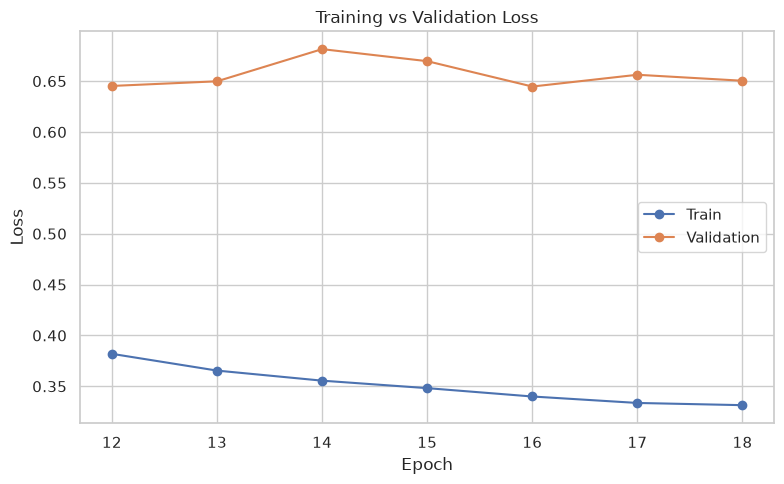

In [61]:
# ============================================================
# Training Curves
# ============================================================

history_df = pd.DataFrame(history)

# Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    marker="o",
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_accuracy"],
    marker="o",
    label="Validation"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "accuracy_curve.png",
    dpi=300
)

plt.show()

# Loss
plt.figure(figsize=(8,5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train"
)

plt.plot(
    history_df["epoch"],
    history_df["validation_loss"],
    marker="o",
    label="Validation"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "loss_curve.png",
    dpi=300
)

plt.show()

# Notebook Summary

## Completed

- Loaded Chest X-ray Dataset
- Built EfficientNet-B2 Model
- Applied Data Augmentation
- Trained using AdamW Optimizer
- Applied Early Stopping
- Saved Best Model
- Saved Training History
- Evaluated on Test Set

## Outputs

- best_model.pth
- training_history.csv
- accuracy_curve.png
- loss_curve.png

Next Notebook:
04_Model_Evaluation.ipynb